
A probabilistic model that learns to score responses based on pairwise human preferences. It answers: "Given two responses, which would humans prefer?"

- Main Bradley-Terry
$P(y_w \succ y_l \mid x) = \sigma\left( r_\varphi(x, y_w) - r_\varphi(x, y_l) \right)$

- Sigmoid
$\sigma(z) = \frac{1}{1 + e^{-z}}$

- Loss
$\mathcal{L} = -\log \sigma\left( r_\varphi(x, y_w) - r_\varphi(x, y_l) \right)$

- Batch Loss
$\mathcal{L}_{batch} = \frac{1}{N} \sum_{i=1}^{N} -\log \sigma\left( r_\varphi(x_i, y_w^i) - r_\varphi(x_i, y_l^i) \right)$

- Optimization
$\varphi_{t+1} = \varphi_t - \alpha \nabla_\varphi \mathcal{L}(\varphi_t)$

Training Bradley-Terry Reward Model...

Epoch 10/50, Loss: 0.0005
Epoch 20/50, Loss: 0.0001
Epoch 30/50, Loss: 0.0001
Epoch 40/50, Loss: 0.0001
Epoch 50/50, Loss: 0.0000

✓ Training complete!

MODEL PREFERENCE ANALYSIS

Example 1:
  Preferred response score:       0.064
  Dispreferred response score:   -2.146
  Difference (r_w - r_l):        2.210
  P(preferred ≻ dispreferred):  0.9012 (via sigmoid)
  Model confidence:             HIGH

Example 2:
  Preferred response score:      -6.855
  Dispreferred response score:   -4.568
  Difference (r_w - r_l):       -2.287
  P(preferred ≻ dispreferred):  0.0922 (via sigmoid)
  Model confidence:             LOW

Example 3:
  Preferred response score:       1.912
  Dispreferred response score:   -5.100
  Difference (r_w - r_l):        7.011
  P(preferred ≻ dispreferred):  0.9991 (via sigmoid)
  Model confidence:             HIGH

Example 4:
  Preferred response score:       6.435
  Dispreferred response score:  -11.034
  Difference (r_w - r_l):  

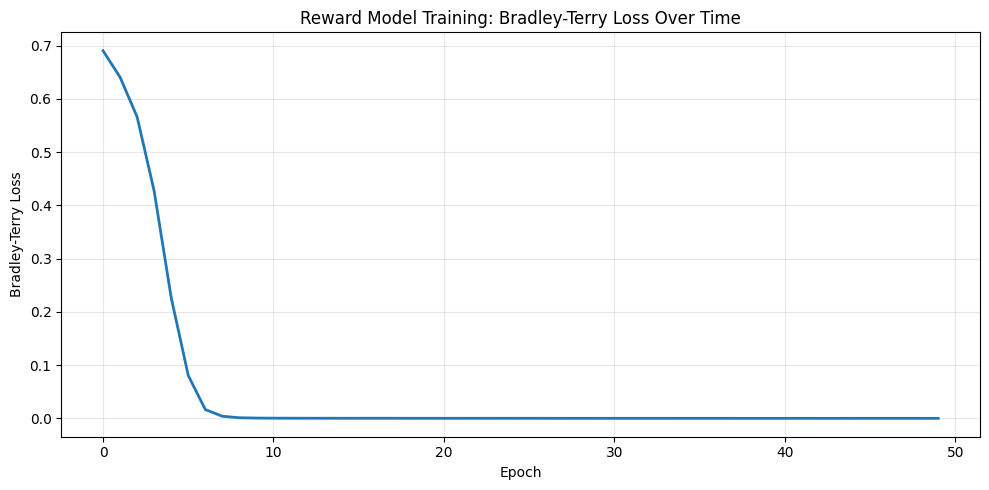

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ============================================================================
# STEP 1: Define the Reward Model
# ============================================================================

class SimpleRewardModel(nn.Module):
    """
    A simple neural network reward model.
    Input: (prompt embedding, response embedding) concatenated
    Output: A scalar reward score
    """
    def __init__(self, embedding_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # Output: single reward score
        )
    
    def forward(self, prompt_emb, response_emb):
        """
        Args:
            prompt_emb: shape (batch_size, embedding_dim)
            response_emb: shape (batch_size, embedding_dim)
        Returns:
            rewards: shape (batch_size, 1) - scalar reward per pair
        """
        concatenated = torch.cat([prompt_emb, response_emb], dim=1)
        return self.net(concatenated)

# ============================================================================
# STEP 2: Define the Bradley-Terry Loss
# ============================================================================

def bradley_terry_loss(reward_preferred, reward_dispreferred):
    """
    Compute Bradley-Terry loss for a batch of preference pairs.
    
    Mathematical formula:
    L = -log(σ(r_w - r_l))
    where σ is sigmoid, r_w is reward of preferred response, r_l is reward of dispreferred
    
    Args:
        reward_preferred: shape (batch_size, 1), rewards for preferred responses
        reward_dispreferred: shape (batch_size, 1), rewards for dispreferred responses
    
    Returns:
        loss: scalar tensor
    """
    # Compute difference
    reward_diff = reward_preferred - reward_dispreferred
    
    # Apply sigmoid: σ(z) = 1 / (1 + e^(-z))
    sigmoid_diff = torch.sigmoid(reward_diff)
    
    # Binary cross-entropy: -log(sigmoid_diff)
    # PyTorch's BCELoss with target=1 computes exactly this
    loss = -torch.log(sigmoid_diff + 1e-8)  # Add small epsilon to avoid log(0)
    
    return loss.mean()

# ============================================================================
# STEP 3: Create Synthetic Data (Preference Pairs)
# ============================================================================

def create_synthetic_data(num_samples=100, embedding_dim=64):
    """
    Create synthetic prompt-response pairs with preferences.
    
    In reality:
    - Prompts: queries from users
    - Responses: different model outputs for same prompt
    - Preferences: which response humans prefer
    """
    np.random.seed(42)
    torch.manual_seed(42)
    
    # Generate random embeddings
    prompt_embeddings = torch.randn(num_samples, embedding_dim)
    response_preferred = torch.randn(num_samples, embedding_dim)
    response_dispreferred = torch.randn(num_samples, embedding_dim)
    
    return prompt_embeddings, response_preferred, response_dispreferred

# ============================================================================
# STEP 4: Training Loop
# ============================================================================

def train_bradley_terry(num_epochs=50, batch_size=16, embedding_dim=64):
    """
    Full training pipeline for Bradley-Terry reward model.
    """
    # Initialize model
    model = SimpleRewardModel(embedding_dim=embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Create data
    prompts, preferred_responses, dispreferred_responses = create_synthetic_data(
        num_samples=100, embedding_dim=embedding_dim
    )
    
    dataset = TensorDataset(prompts, preferred_responses, dispreferred_responses)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    losses = []
    
    # Training loop
    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_prompts, batch_preferred, batch_dispreferred in dataloader:
            # Forward pass
            reward_preferred = model(batch_prompts, batch_preferred)
            reward_dispreferred = model(batch_prompts, batch_dispreferred)
            
            # Compute Bradley-Terry loss
            loss = bradley_terry_loss(reward_preferred, reward_dispreferred)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return model, losses

# ============================================================================
# STEP 5: Visualization
# ============================================================================

def visualize_training(losses):
    """Plot training loss over time."""
    plt.figure(figsize=(10, 5))
    plt.plot(losses, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Bradley-Terry Loss')
    plt.title('Reward Model Training: Bradley-Terry Loss Over Time')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# STEP 6: Inspect Learned Preferences
# ============================================================================

def inspect_model(model, num_samples=5):
    """
    See how the trained model scores different responses.
    """
    model.eval()
    
    with torch.no_grad():
        prompts, preferred, dispreferred = create_synthetic_data(
            num_samples=num_samples, embedding_dim=64
        )
        
        rewards_preferred = model(prompts, preferred).squeeze()
        rewards_dispreferred = model(prompts, dispreferred).squeeze()
        
        print("\n" + "="*70)
        print("MODEL PREFERENCE ANALYSIS")
        print("="*70)
        
        for i in range(num_samples):
            r_w = rewards_preferred[i].item()
            r_l = rewards_dispreferred[i].item()
            
            # Compute probability using Bradley-Terry formula
            prob = torch.sigmoid(torch.tensor(r_w - r_l)).item()
            
            print(f"\nExample {i+1}:")
            print(f"  Preferred response score:     {r_w:7.3f}")
            print(f"  Dispreferred response score:  {r_l:7.3f}")
            print(f"  Difference (r_w - r_l):      {r_w - r_l:7.3f}")
            print(f"  P(preferred ≻ dispreferred):  {prob:.4f} (via sigmoid)")
            print(f"  Model confidence:             {'HIGH' if prob > 0.7 else 'MEDIUM' if prob > 0.55 else 'LOW'}")

# ============================================================================
# RUN THE FULL PIPELINE
# ============================================================================

if __name__ == "__main__":
    print("Training Bradley-Terry Reward Model...\n")
    model, losses = train_bradley_terry(num_epochs=50, batch_size=16, embedding_dim=64)
    
    print("\n✓ Training complete!")
    
    # Inspect learned preferences
    inspect_model(model, num_samples=5)
    
    # Plot training curve
    visualize_training(losses)